# Proyecto Final - Integracion de Datos y Prospectiva

## Caso de estudio

En este trabajo se realiza la integracion de dos bases de datos de reseñas de Amazon, con el fin de analizar la satisfaccion de los clientes a partir de variables numericas comunes.

## Objetivo

Aplicar modelos de integracion de datos vistos en clase para agrupar las reseñas de los clientes y obtener hallazgos que apoyen la toma de decisiones.

## Integrantes del grupo
- Juan José Márquez
- Jose Miguel Jaramillo
- Mario Guerrero


---
## 1.  Introducción

Amazon es la plataforma de comercio electrónico más grande del mundo, con millones de transacciones diarias. La satisfacción del cliente se convierte en un activo estratégico que determina la fidelización, el retorno de compra y la reputación de la marca.

Las reseñas de los clientes representan una fuente masiva de datos no estructurados que, al ser procesados y analizados, permiten identificar **patrones de comportamiento, segmentos de satisfacción y áreas de mejora** en la experiencia de compra.

En este proyecto se integran dos bases de datos de reseñas de Amazon con diferente enfoque:
- **Dataset 1 (reviews.csv):** Reseñas de productos de ropa, con puntajes de sentimiento pre-calculados.
- **Dataset 2 (Amazon_Reviews.csv):** Reseñas generales de la experiencia con la plataforma Amazon.

La integración se realiza sobre las variables comunes (rating, sentiment_score, text_length) aplicando modelos de clustering para segmentar a los clientes según su nivel de satisfacción.

---
## 2.  Instalación de dependencias

In [1]:
# Se instalan las librerias necesarias para sentimiento y logica borrosa
!pip install -q vaderSentiment scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 31.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


---
## 3.  Importación de librerías

In [3]:
# Se cargan las librerias de trabajo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import skfuzzy as fuzz


---
## 4. Carga de las bases de datos


In [4]:
# Ruta de los archivos de trabajo
nxl1 = '/content/reviews.csv'
nxl2 = '/content/Amazon_Reviews.csv'

# Se cargan las bases de datos
XDB1 = pd.read_csv(nxl1, encoding='utf-8')
XDB2 = pd.read_csv(nxl2, encoding='utf-8', engine='python', on_bad_lines='skip')


df1 = XDB1.copy()
df2 = XDB2.copy()

print('Base de datos 1 - reviews.csv')
print('Registros:', len(XDB1))
display(XDB1.head())

print('Base de datos 2 - Amazon_Reviews.csv')
print('Registros:', len(XDB2))
display(XDB2.head())


Base de datos 1 - reviews.csv
Registros: 6327


,s.no,helpfulVoteCount,images/0,images/1,images/2,images/3,images/4,images/5,images/6,images/7,...,reviewID,reviewMetadata,reviewPosition,reviewText,reviewTitle,reviewURL,verifiedPurchase,videos/0,cleaned_review_text,sentiment_score
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R2AUQFPJY5ERCZ,"Reviewed in the United States on March 6, 2025",1,‚úçÔ∏è The COOFANDY Men's Polo Shirt is a fant...,Stylish and Lightweight COOFANDY Polo Shirt,https://www.amazon.com/review/R2AUQFPJY5ERCZ,False,NaN,coofandy men polo shirt fantastic blend style ...,0.292024
1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R1YNLJ0QFLB1VT,"Reviewed in the United States on March 7, 2025",1,I love these. They look good. They fit well. T...,New favorite shirts,https://www.amazon.com/review/R1YNLJ0QFLB1VT,False,NaN,love look good fit well comfortable breathable...,0.560000
2,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R11LIYW9RMDK9R,"Reviewed in the United States on February 27, ...",2,My expectations were low -- how good could shi...,Incredibly Good Deal,https://www.amazon.com/review/R11LIYW9RMDK9R,False,NaN,expectation low good could shirt sell one mist...,0.192321
3,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R3K9X391DJNTPZ,"Reviewed in the United States on February 26, ...",3,This 3-pack of multi-color shirts is really a ...,Higher quality & breathable 3-pack shirt set t...,https://www.amazon.com/review/R3K9X391DJNTPZ,False,NaN,pack multicolor shirt really brainer wear type...,0.307949
4,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,RP17IW9ZKENDZ,"Reviewed in the United States on February 20, ...",4,With these three polo shirts I was very satisf...,Pocket Polos Looks Good,https://www.amazon.com/review/RP17IW9ZKENDZ,False,NaN,three polo shirt satisfied quality material go...,0.250000


Base de datos 2 - Amazon_Reviews.csv
Registros: 21214


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [5]:
# Exploracion de la base de datos 1
print('Base de datos 1 - Reseñas de productos de ropa')
display(df1[['productASIN', 'rating', 'helpfulVoteCount', 'sentiment_score',
             'reviewPosition', 'verifiedPurchase', 'reviewTitle']].head())

print('Estadisticas descriptivas')
display(df1[['rating', 'helpfulVoteCount', 'sentiment_score', 'reviewPosition']].describe().round(3))

print('Valores nulos')
display(df1[['rating', 'helpfulVoteCount', 'sentiment_score', 'reviewPosition']].isnull().sum())


Base de datos 1 - Reseñas de productos de ropa


,productASIN,rating,helpfulVoteCount,sentiment_score,reviewPosition,verifiedPurchase,reviewTitle
0,B0DLGB4RYH,5.0,0,0.292024,1,False,Stylish and Lightweight COOFANDY Polo Shirt
1,B0DRXF62JH,5.0,0,0.560000,1,False,New favorite shirts
2,B0DRXF62JH,4.0,0,0.192321,2,False,Incredibly Good Deal
3,B0DRXF62JH,5.0,0,0.307949,3,False,Higher quality & breathable 3-pack shirt set t...
4,B0DRXF62JH,5.0,0,0.250000,4,False,Pocket Polos Looks Good


Estadisticas descriptivas


,rating,helpfulVoteCount,sentiment_score,reviewPosition
count,6320.000,6327.000,6327.000,6327.000
mean,4.533,3.336,0.308,5.375
std,0.856,19.091,0.218,2.890
min,1.000,0.000,-1.000,1.000
25%,4.000,0.000,0.169,3.000
50%,5.000,0.000,0.300,5.000
75%,5.000,2.000,0.450,8.000
max,5.000,710.000,1.000,10.000


Valores nulos


,0
rating,7
helpfulVoteCount,0
sentiment_score,0
reviewPosition,0


In [6]:
# Exploracion de la base de datos 2
print('Base de datos 2 - Reseñas del servicio general de Amazon')
display(df2[['Reviewer Name', 'Country', 'Rating', 'Review Count', 'Review Title']].head())

print('Distribucion de paises')
display(df2['Country'].value_counts().head(10))

print('Distribucion de ratings')
display(df2['Rating'].value_counts())


Base de datos 2 - Reseñas del servicio general de Amazon


,Reviewer Name,Country,Rating,Review Count,Review Title
0,Eugene ath,US,Rated 1 out of 5 stars,1 review,A Store That Doesn't Want to Sell Anything
1,Daniel ohalloran,GB,Rated 1 out of 5 stars,9 reviews,Had multiple orders one turned up and…
2,p fisher,GB,Rated 1 out of 5 stars,90 reviews,I informed these reprobates
3,Greg Dunn,AU,Rated 1 out of 5 stars,5 reviews,Advertise one price then increase it on website
4,Sheila Hannah,GB,Rated 1 out of 5 stars,8 reviews,If I could give a lower rate I would


Distribucion de paises


,count
Country,
US,9286
GB,7294
CA,708
IN,629
IE,242
DK,239
NL,215
AU,186
DE,181


Distribucion de ratings


,count
Rating,
Rated 1 out of 5 stars,13123
Rated 5 out of 5 stars,4528
Rated 4 out of 5 stars,1292
Rated 2 out of 5 stars,1227
Rated 3 out of 5 stars,885


---
## 5.  Preprocesamiento

Se construyen las variables numéricas equivalentes en ambos datasets para permitir la integración:
- **`rating`** → normalizado en escala 1–5
- **`sentiment_score`** → calculado con VADER para Dataset 2 (compound score: −1 a 1)
- **`text_length`** → longitud del texto de la reseña (proxy de elaboración del feedback)

In [7]:
# Dataset 1

# Eliminar nulos en variables clave
df1_clean = df1.dropna(subset=['rating', 'sentiment_score']).copy()

# Calcular longitud del texto
df1_clean['text_length'] = df1_clean['reviewText'].fillna('').astype(str).str.len()

# Normalizar helpfulVoteCount (log para reducir efecto de outliers)
df1_clean['helpful_log'] = np.log1p(df1_clean['helpfulVoteCount'])

# Seleccionar features de clustering
features_df1 = df1_clean[['rating', 'sentiment_score', 'text_length', 'helpful_log']].copy()

print(f' Dataset 1 limpio: {df1_clean.shape[0]:,} registros')
display(features_df1.describe().round(3))

 Dataset 1 limpio: 6,320 registros


,rating,sentiment_score,text_length,helpful_log
count,6320.000,6320.000,6320.000,6320.000
mean,4.533,0.308,332.164,0.522
std,0.856,0.218,500.160,0.980
min,1.000,-1.000,0.000,0.000
25%,4.000,0.170,82.000,0.000
50%,5.000,0.300,185.500,0.000
75%,5.000,0.450,385.000,1.099
max,5.000,1.000,15330.000,6.567


In [8]:
# Dataset 2

# Extraer rating numérico
df2['rating'] = df2['Rating'].str.extract(r'(\d+)').astype(float)

# Extraer número de reviews del reviewer
df2['review_count_num'] = df2['Review Count'].str.extract(r'(\d+)').astype(float)

# Calcular longitud del texto
df2['text_length'] = df2['Review Text'].fillna('').astype(str).str.len()

# Calcular sentiment_score con VADER
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if pd.isna(text) or str(text).strip() == '':
        return 0.0
    return analyzer.polarity_scores(str(text))['compound']

# Tomar muestra representativa para eficiencia (20,000 registros)
df2_sample = df2.dropna(subset=['rating']).sample(n=min(20000, len(df2)), random_state=42).copy()
df2_sample['sentiment_score'] = df2_sample['Review Text'].apply(get_sentiment)
df2_sample['helpful_log'] = np.log1p(df2_sample['review_count_num'].fillna(1))

features_df2 = df2_sample[['rating', 'sentiment_score', 'text_length', 'helpful_log']].copy()

print(f' Dataset 2 limpio: {df2_sample.shape[0]:,} registros')
display(features_df2.describe().round(3))

 Dataset 2 limpio: 20,000 registros


,rating,sentiment_score,text_length,helpful_log
count,20000.000,20000.000,20000.000,20000.000
mean,2.185,0.028,460.999,1.638
std,1.676,0.668,517.291,0.948
min,1.000,-0.999,10.000,0.693
25%,1.000,-0.639,147.000,0.693
50%,1.000,0.000,315.000,1.386
75%,4.000,0.694,583.000,2.197
max,5.000,0.999,9951.000,6.452


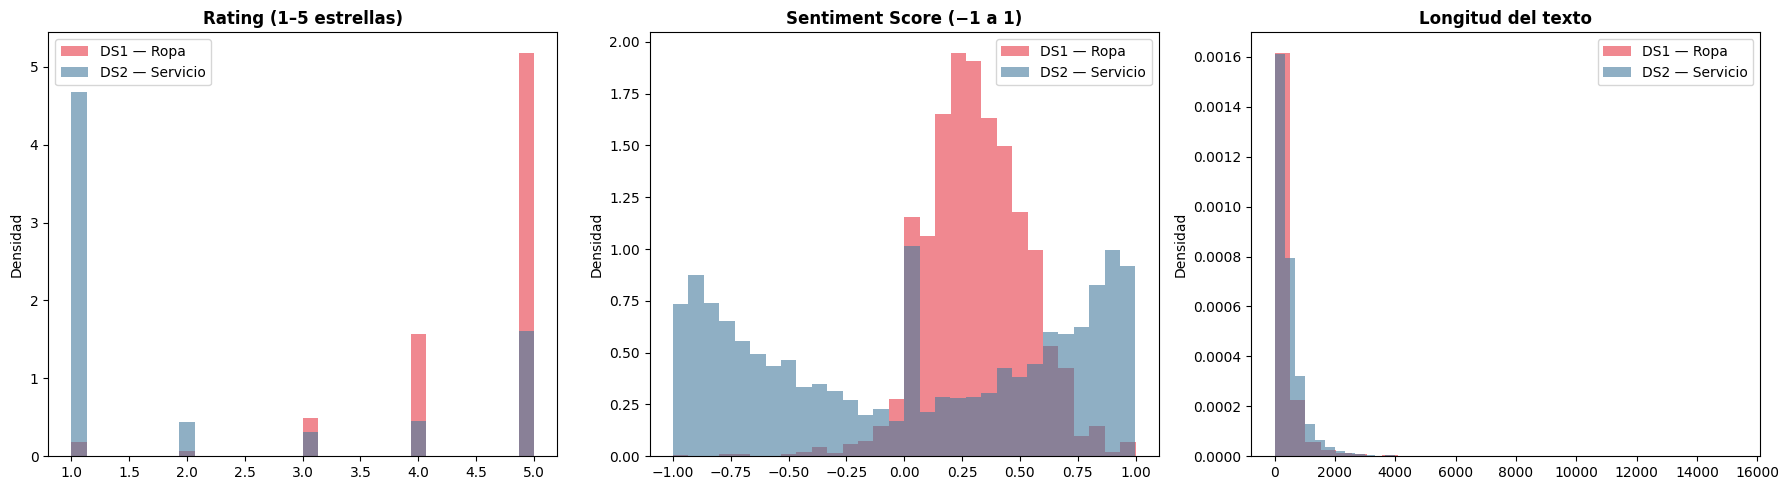

 Gráfica guardada: eda_comparativo.png


In [9]:
# Configuracion visual para las graficas de analisis
COLOR_PALETTE = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261']
sns.set_palette(COLOR_PALETTE)

# Visualización EDA comparativa

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vars_to_plot = [
    ('rating', 'Rating (1–5 estrellas)'),
    ('sentiment_score', 'Sentiment Score (−1 a 1)'),
    ('text_length', 'Longitud del texto')
]

for ax, (var, label) in zip(axes, vars_to_plot):
    ax.hist(features_df1[var].dropna(), bins=30, alpha=0.6,
            color=COLOR_PALETTE[0], label='DS1 — Ropa', density=True)
    ax.hist(features_df2[var].dropna(), bins=30, alpha=0.6,
            color=COLOR_PALETTE[1], label='DS2 — Servicio', density=True)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Densidad')
    ax.legend()

plt.tight_layout()
plt.show()
print(' Gráfica guardada: eda_comparativo.png')

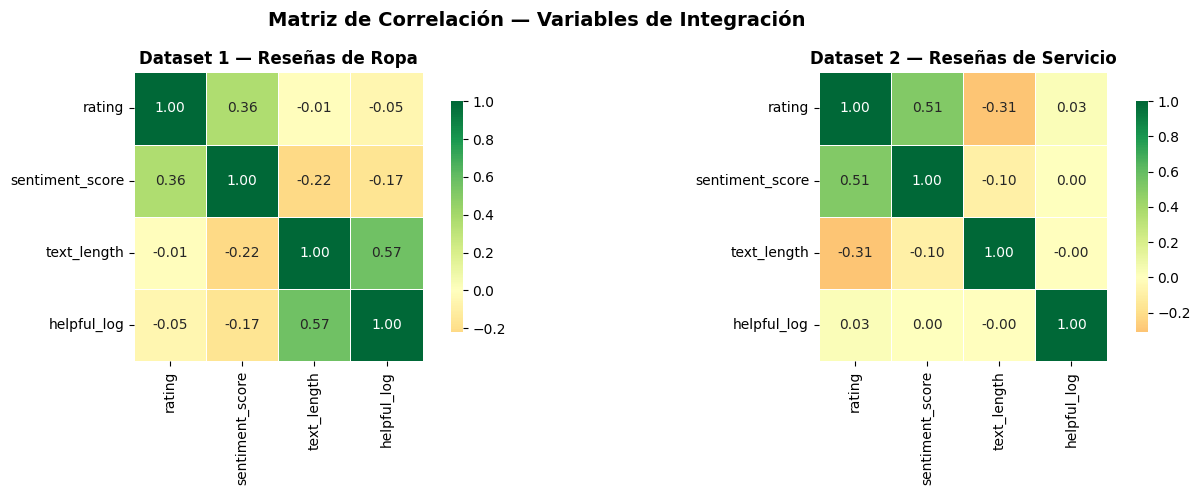

In [10]:
# ── Mapa de correlación por dataset ───────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, features, title in [
    (ax1, features_df1, 'Dataset 1 — Reseñas de Ropa'),
    (ax2, features_df2, 'Dataset 2 — Reseñas de Servicio')
]:
    corr = features.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Matriz de Correlación — Variables de Integración',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6.  Clusterización Estática — K-Means

K-Means es el algoritmo de clusterización más ampliamente utilizado.

**Pasos:**
1. Escalar las variables (media 0, desviación 1)
2. Determinar K óptimo con el método del codo y metrica Score
3. Aplicar K-Means a cada dataset individualmente
4. Interpretar los clusters resultantes

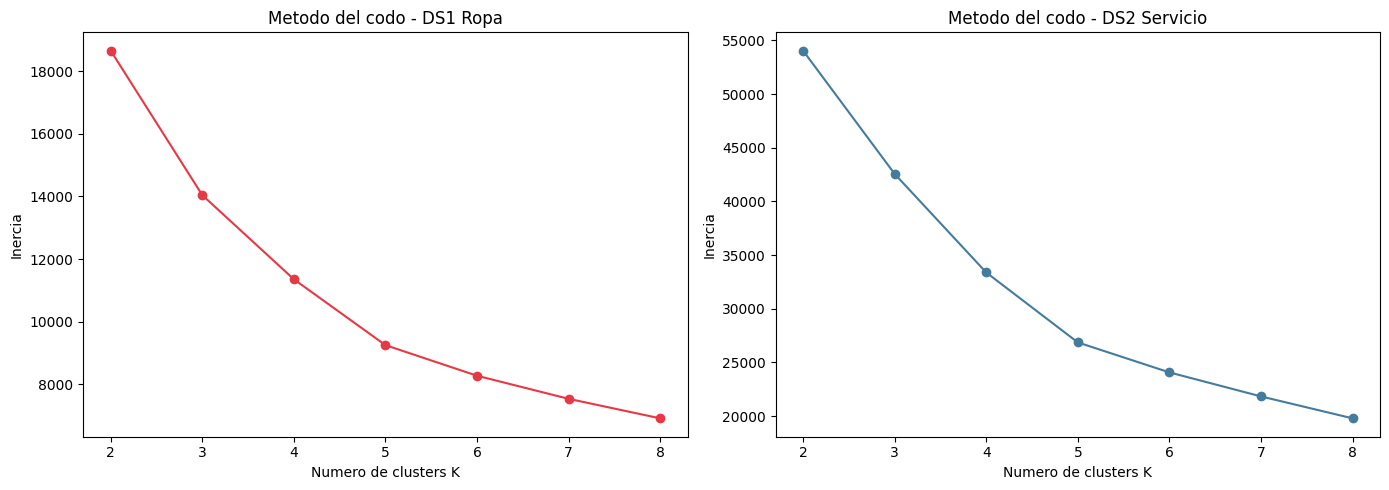

In [12]:
# Escalado y metodo del codo

scaler = StandardScaler()

# Escalar ambos datasets
X1 = scaler.fit_transform(features_df1.dropna())
X2 = scaler.fit_transform(features_df2.dropna())

inertias_1 = []
inertias_2 = []
K_range = range(2, 9)

for k in K_range:
    km1 = KMeans(n_clusters=k, random_state=42, n_init=10)
    km1.fit(X1)
    inertias_1.append(km1.inertia_)

    km2 = KMeans(n_clusters=k, random_state=42, n_init=10)
    km2.fit(X2)
    inertias_2.append(km2.inertia_)

# Grafica del codo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias_1, 'o-', color=COLOR_PALETTE[0])
axes[0].set_title('Metodo del codo - DS1 Ropa')
axes[0].set_xlabel('Numero de clusters K')
axes[0].set_ylabel('Inercia')

axes[1].plot(list(K_range), inertias_2, 'o-', color=COLOR_PALETTE[1])
axes[1].set_title('Metodo del codo - DS2 Servicio')
axes[1].set_xlabel('Numero de clusters K')
axes[1].set_ylabel('Inercia')

plt.tight_layout()
plt.show()


In [13]:
# K-Means final con K=3
# Se elige K=3 por interpretabilidad: segmentos Insatisfecho / Neutro / Satisfecho

K_OPTIMAL = 3

km1 = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
km2 = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)

idx1 = features_df1.dropna().index
idx2 = features_df2.dropna().index

labels_km1 = km1.fit_predict(X1)
labels_km2 = km2.fit_predict(X2)

df1_clean.loc[idx1, 'cluster_kmeans'] = labels_km1
df2_sample.loc[idx2, 'cluster_kmeans'] = labels_km2

print('K-Means aplicado con K=3')
print('Clusters Dataset 1:', np.unique(labels_km1))
print('Clusters Dataset 2:', np.unique(labels_km2))


K-Means aplicado con K=3
Clusters Dataset 1: [0 1 2]
Clusters Dataset 2: [0 1 2]


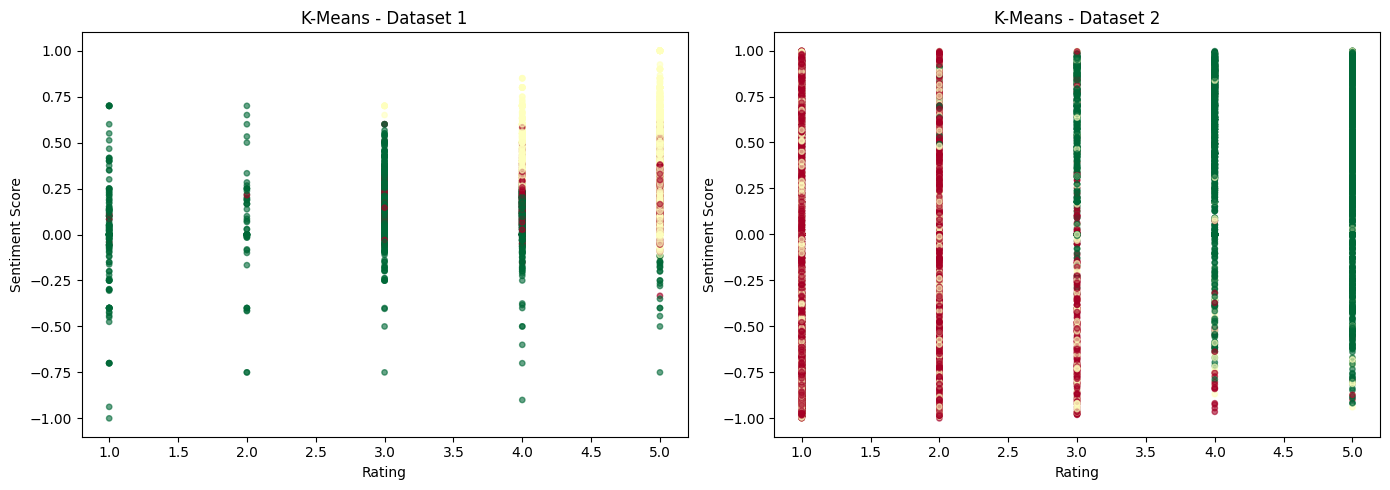

In [14]:
# Visualizacion K-Means

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(profile1['rating'] if 'profile1' in globals() else df1_clean.loc[idx1, 'rating'],
                profile1['sentiment_score'] if 'profile1' in globals() else df1_clean.loc[idx1, 'sentiment_score'],
                c=labels_km1, cmap='RdYlGn', alpha=0.6, s=15)
axes[0].set_title('K-Means - Dataset 1')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Sentiment Score')

axes[1].scatter(df2_sample.loc[idx2, 'rating'],
                df2_sample.loc[idx2, 'sentiment_score'],
                c=labels_km2, cmap='RdYlGn', alpha=0.6, s=15)
axes[1].set_title('K-Means - Dataset 2')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Sentiment Score')

plt.tight_layout()
plt.show()



PERFIL DE CLUSTERS — Dataset 1 (K-Means)


,rating,sentiment_score,text_length,helpfulVoteCount
cluster_kmeans,,,,
0,4.656,0.223,994.617,18.737
1,4.867,0.386,194.493,0.316
2,3.213,0.095,267.217,1.191



PERFIL DE CLUSTERS — Dataset 2 (K-Means)


,rating,sentiment_score,text_length,helpful_log
cluster_kmeans,,,,
0,1.148,-0.200,572.547,1.073
1,1.216,-0.205,561.620,2.969
2,4.639,0.581,199.559,1.627


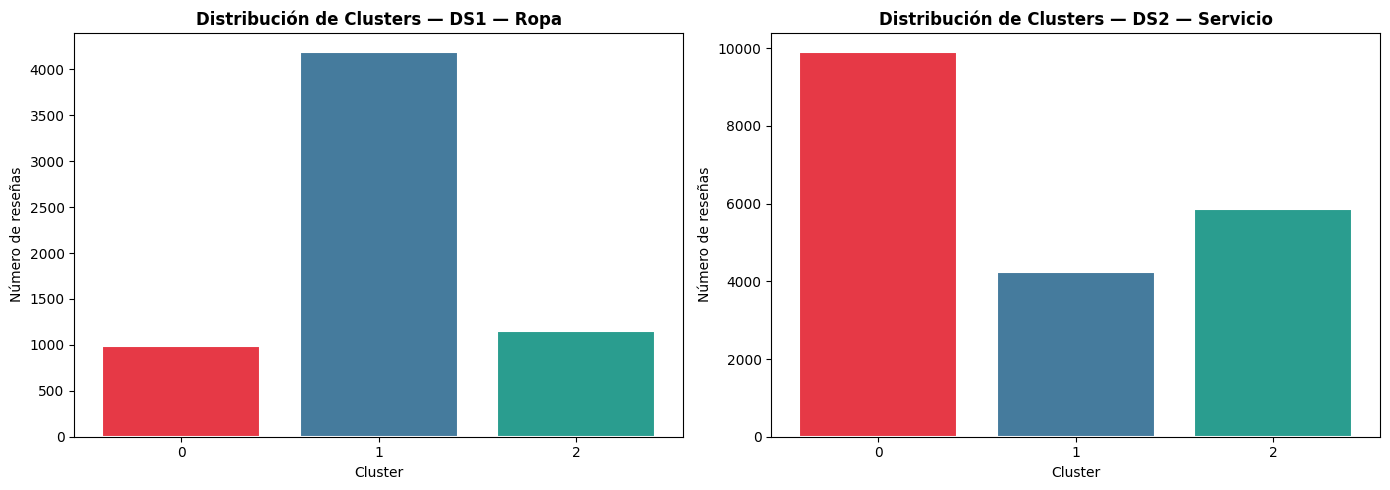

In [15]:
#  Perfil de clusters K-Means
print('\nPERFIL DE CLUSTERS — Dataset 1 (K-Means)')
profile1 = df1_clean.loc[idx1].copy()
profile1['cluster_kmeans'] = labels_km1
display(
    profile1.groupby('cluster_kmeans')[['rating', 'sentiment_score', 'text_length', 'helpfulVoteCount']]
    .mean().round(3)
)

print('\nPERFIL DE CLUSTERS — Dataset 2 (K-Means)')
profile2 = df2_sample.loc[idx2].copy()
profile2['cluster_kmeans'] = labels_km2
display(
    profile2.groupby('cluster_kmeans')[['rating', 'sentiment_score', 'text_length', 'helpful_log']]
    .mean().round(3)
)

# Distribución de clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, labels, title in [
    (axes[0], labels_km1, 'DS1 — Ropa'),
    (axes[1], labels_km2, 'DS2 — Servicio')
]:
    unique, counts = np.unique(labels, return_counts=True)
    bars = ax.bar(unique, counts, color=COLOR_PALETTE[:3], edgecolor='white', linewidth=1.5)
    ax.set_title(f'Distribución de Clusters — {title}', fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Número de reseñas')
    ax.set_xticks([0, 1, 2])

plt.tight_layout()
plt.show()

---
## 7.  Integración Dinámica — K-Medoids

K-Medoids es una variante más robusta de K-Means.

**Ventajas sobre K-Means:**
- Robustez ante outliers (usa distancia de Manhattan)
- Los centros son observaciones reales interpretables
- Mejor para datos con distribuciones asimétricas

**Integración dinámica:** Se aplica sobre el dataset **integrado** (unión de DS1 + DS2) usando las variables comunes normalizadas.

In [16]:
# Integración de datasets
# Preparar Dataset 1 para integración
ds1_int = df1_clean.loc[idx1, ['rating', 'sentiment_score', 'text_length', 'helpful_log']].copy()
ds1_int['source'] = 'DS1_Ropa'
ds1_int = ds1_int.dropna()

# Preparar Dataset 2 para integración
ds2_int = df2_sample.loc[idx2, ['rating', 'sentiment_score', 'text_length', 'helpful_log']].copy()
ds2_int['source'] = 'DS2_Servicio'
ds2_int = ds2_int.dropna()

# Dataset integrado
df_integrated = pd.concat([ds1_int, ds2_int], ignore_index=True)

print(f' Dataset integrado: {df_integrated.shape[0]:,} registros')
print(f'   - Dataset 1 (Ropa):     {len(ds1_int):,} registros')
print(f'   - Dataset 2 (Servicio): {len(ds2_int):,} registros')
print('\nVariables de integración:')
display(df_integrated.drop(columns='source').describe().round(3))

 Dataset integrado: 26,320 registros
   - Dataset 1 (Ropa):     6,320 registros
   - Dataset 2 (Servicio): 20,000 registros

Variables de integración:


,rating,sentiment_score,text_length,helpful_log
count,26320.000,26320.000,26320.000,26320.000
mean,2.749,0.095,430.063,1.370
std,1.821,0.604,516.163,1.068
min,1.000,-1.000,0.000,0.000
25%,1.000,-0.471,125.000,0.693
50%,2.000,0.204,280.000,1.099
75%,5.000,0.600,541.000,1.946
max,5.000,1.000,15330.000,6.567


In [17]:
# Modelo de integracion con K-Medoids

def fit_kmedoids(X, n_clusters=3, metric='manhattan', max_iter=100, random_state=42):
    rng = np.random.RandomState(random_state)
    medoid_indices = rng.choice(len(X), n_clusters, replace=False)

    for _ in range(max_iter):
        D = pairwise_distances(X, X[medoid_indices], metric=metric)
        grupos = np.argmin(D, axis=1)
        nuevos_medoides = medoid_indices.copy()

        for i in range(n_clusters):
            ind = np.where(grupos == i)[0]
            if len(ind) > 0:
                D_interna = pairwise_distances(X[ind], metric=metric)
                mejor = np.argmin(D_interna.sum(axis=1))
                nuevos_medoides[i] = ind[mejor]

        if np.array_equal(nuevos_medoides, medoid_indices):
            break
        medoid_indices = nuevos_medoides

    D = pairwise_distances(X, X[medoid_indices], metric=metric)
    grupos = np.argmin(D, axis=1)
    return grupos, medoid_indices

# Se normaliza la base integrada
scaler_int = StandardScaler()
X_int = scaler_int.fit_transform(df_integrated.drop(columns='source'))

# Se toma una muestra para que el modelo corra mas rapido
SAMPLE_SIZE = min(8000, len(X_int))
idx_sample = np.random.RandomState(42).choice(len(X_int), SAMPLE_SIZE, replace=False)
X_sample = X_int[idx_sample]
source_sample = df_integrated['source'].iloc[idx_sample].values

labels_kmed, medoid_indices = fit_kmedoids(X_sample, n_clusters=3, metric='manhattan', random_state=42)
kmed_centers = X_sample[medoid_indices]


print('K-Medoids aplicado sobre la base integrada')

# Medoides en valores originales
df_medoids = pd.DataFrame(
    scaler_int.inverse_transform(kmed_centers),
    columns=['rating', 'sentiment_score', 'text_length', 'helpful_log']
)
df_medoids['cluster'] = range(3)
df_medoids['source'] = source_sample[medoid_indices]
display(df_medoids.round(3))


K-Medoids aplicado sobre la base integrada


,rating,sentiment_score,text_length,helpful_log,cluster,source
0,5.0,0.300,125.0,0.000,0,DS1_Ropa
1,1.0,-0.414,440.0,1.386,1,DS2_Servicio
2,5.0,0.687,182.0,1.609,2,DS2_Servicio


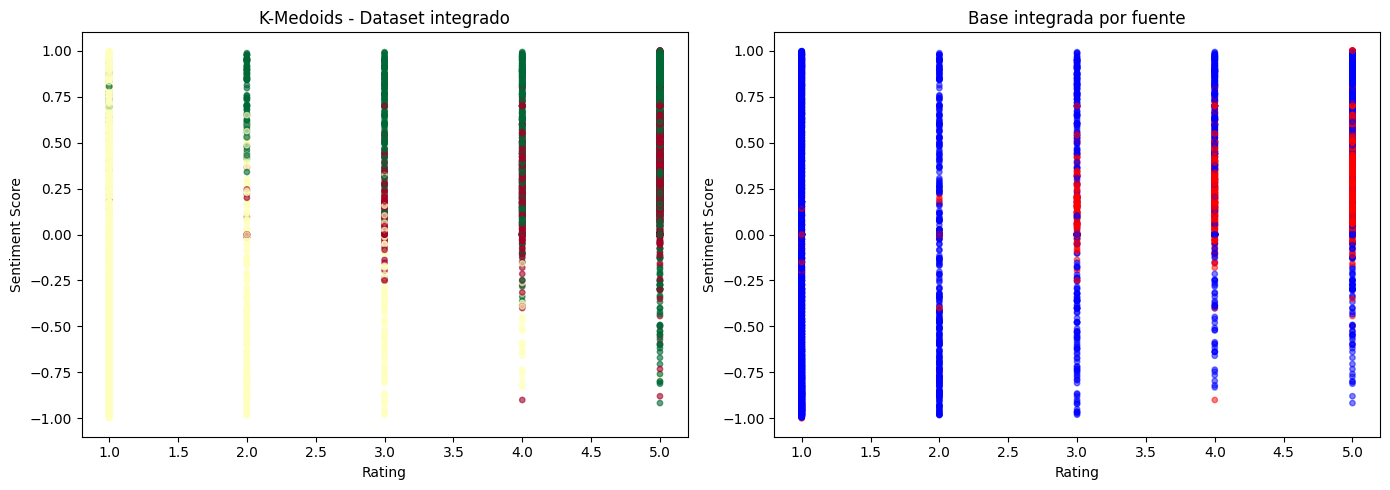

In [18]:
# Visualizacion K-Medoids

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

X_original = pd.DataFrame(
    scaler_int.inverse_transform(X_sample),
    columns=['rating', 'sentiment_score', 'text_length', 'helpful_log']
)
X_original['cluster'] = labels_kmed
X_original['source'] = source_sample

axes[0].scatter(X_original['rating'], X_original['sentiment_score'],
                c=X_original['cluster'], cmap='RdYlGn', alpha=0.6, s=15)
axes[0].set_title('K-Medoids - Dataset integrado')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Sentiment Score')

colors_source = ['red' if s == 'DS1_Ropa' else 'blue' for s in X_original['source']]
axes[1].scatter(X_original['rating'], X_original['sentiment_score'],
                c=colors_source, alpha=0.5, s=15)
axes[1].set_title('Base integrada por fuente')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Sentiment Score')

plt.tight_layout()
plt.show()


 PERFIL DE CLUSTERS — K-Medoids (Dataset Integrado)


,rating,sentiment_score,text_length
cluster,,,
0,4.587,0.298,199.514
1,1.142,-0.233,565.298
2,4.499,0.587,336.286



DISTRIBUCIÓN POR FUENTE DE DATOS EN CADA CLUSTER:


source,DS1_Ropa,DS2_Servicio
cluster,,
0,86.5,13.5
1,1.7,98.3
2,19.1,80.9


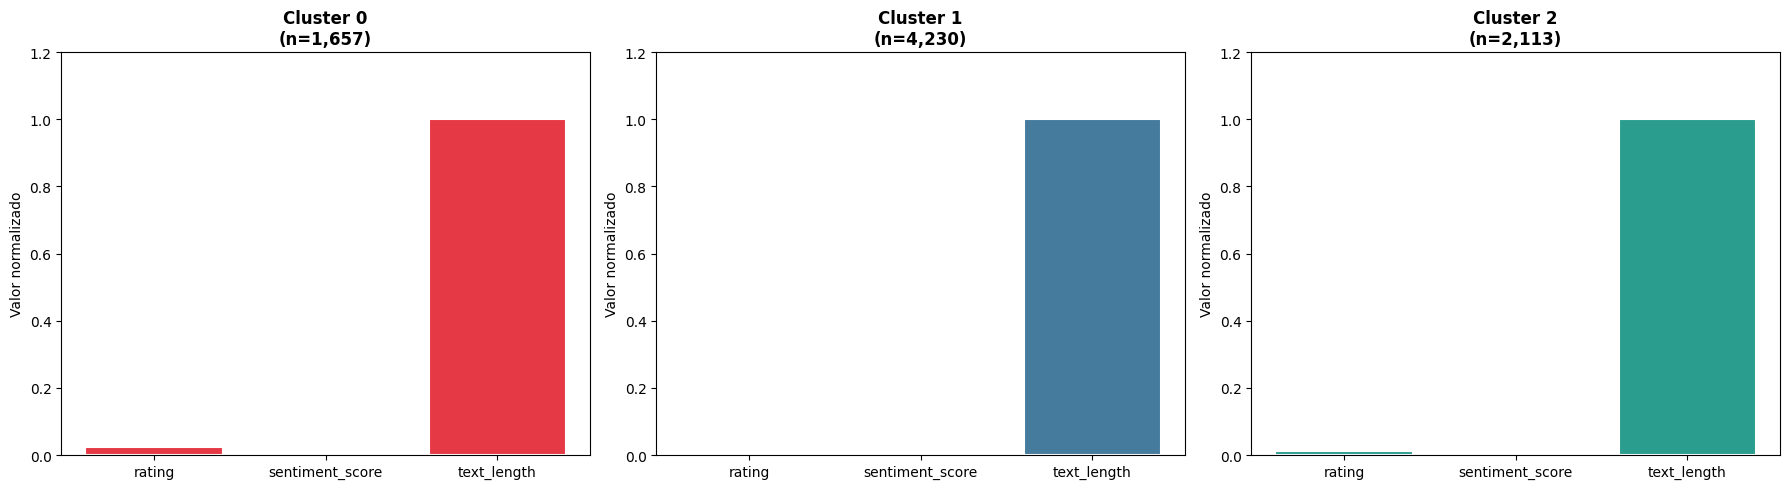

In [19]:
#  Perfil de clusters K-Medoids
df_kmed_result = pd.DataFrame(X_sample, columns=['rating_sc', 'sentiment_sc', 'text_sc', 'helpful_sc'])
df_kmed_result['cluster'] = labels_kmed
df_kmed_result['source'] = source_sample

# Perfil en valores originales
df_orig_sample = pd.DataFrame(
    scaler_int.inverse_transform(X_sample),
    columns=['rating', 'sentiment_score', 'text_length', 'helpful_log']
)
df_orig_sample['cluster'] = labels_kmed
df_orig_sample['source'] = source_sample

print(' PERFIL DE CLUSTERS — K-Medoids (Dataset Integrado)')
display(df_orig_sample.groupby('cluster')[['rating', 'sentiment_score', 'text_length']].mean().round(3))

print('\nDISTRIBUCIÓN POR FUENTE DE DATOS EN CADA CLUSTER:')
display(pd.crosstab(df_orig_sample['cluster'], df_orig_sample['source'],
                    normalize='index').round(3) * 100)

# Radar chart de perfiles
fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw=dict(polar=False))

vars_profile = ['rating', 'sentiment_score', 'text_length']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

profile_means = df_orig_sample.groupby('cluster')[vars_profile].mean()

for i, ax in enumerate(axes):
    vals = profile_means.loc[i]
    bars = ax.bar(vars_profile, vals / vals.max(), color=COLOR_PALETTE[i],
                  edgecolor='white', linewidth=1.5)
    ax.set_title(f'{cluster_names[i]}\n(n={sum(labels_kmed==i):,})', fontweight='bold')
    ax.set_ylim(0, 1.2)
    ax.set_ylabel('Valor normalizado')

plt.tight_layout()
plt.show()

---
## 8.  Integración Borrosa — Lógica Borrosa (Fuzzy C-Means)

La **Lógica Borrosa** (Fuzzy Logic) permite manejar la incertidumbre inherente en las clasificaciones humanas.

**¿Por qué es útil aquí?**  
Un cliente con rating=3 y sentimiento=0.1 no es claramente "satisfecho" ni "insatisfecho" — la lógica borrosa captura esa ambigüedad.

**Variables lingüísticas definidas:**
- **Rating:** Bajo (1-2), Medio (2-4), Alto (4-5)
- **Sentimiento:** Negativo, Neutro, Positivo
- **Satisfacción (salida):** Insatisfecho, Neutral, Satisfecho

In [20]:
# Fuzzy C-Means

# Preparar datos para FCM (usa las 2 variables más informativas)
X_fuzzy = df_integrated[['rating', 'sentiment_score']].dropna().values.T  # shape: (2, N)

# Tomar muestra
N_FUZZY = min(5000, X_fuzzy.shape[1])
idx_fuzz = np.random.RandomState(42).choice(X_fuzzy.shape[1], N_FUZZY, replace=False)
X_fuzz_sample = X_fuzzy[:, idx_fuzz]

print(f'⏳ Aplicando Fuzzy C-Means sobre {N_FUZZY:,} muestras...')

# Fuzzy C-Means
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_fuzz_sample,
    c=3,           # número de clusters
    m=2,           # fuzziness coefficient (m=2 es el estándar)
    error=0.005,
    maxiter=1000,
    init=None,
    seed=42
)

# Cluster con mayor membresía para cada punto
cluster_membership = np.argmax(u, axis=0)

print(f'\n Fuzzy Partition Coefficient (FPC): {fpc:.4f}')
print(f'   (FPC=1 → clustering perfecto, FPC=1/c → completamente borroso)')
print(f'\n Centros de los clusters borrosos:')
df_centers = pd.DataFrame(cntr, columns=['rating', 'sentiment_score'])
df_centers.index.name = 'Cluster'
display(df_centers.round(4))

⏳ Aplicando Fuzzy C-Means sobre 5,000 muestras...

 Fuzzy Partition Coefficient (FPC): 0.8218
   (FPC=1 → clustering perfecto, FPC=1/c → completamente borroso)

 Centros de los clusters borrosos:


,rating,sentiment_score
Cluster,,
0,1.0375,-0.2803
1,3.1761,0.2413
2,4.9383,0.4820


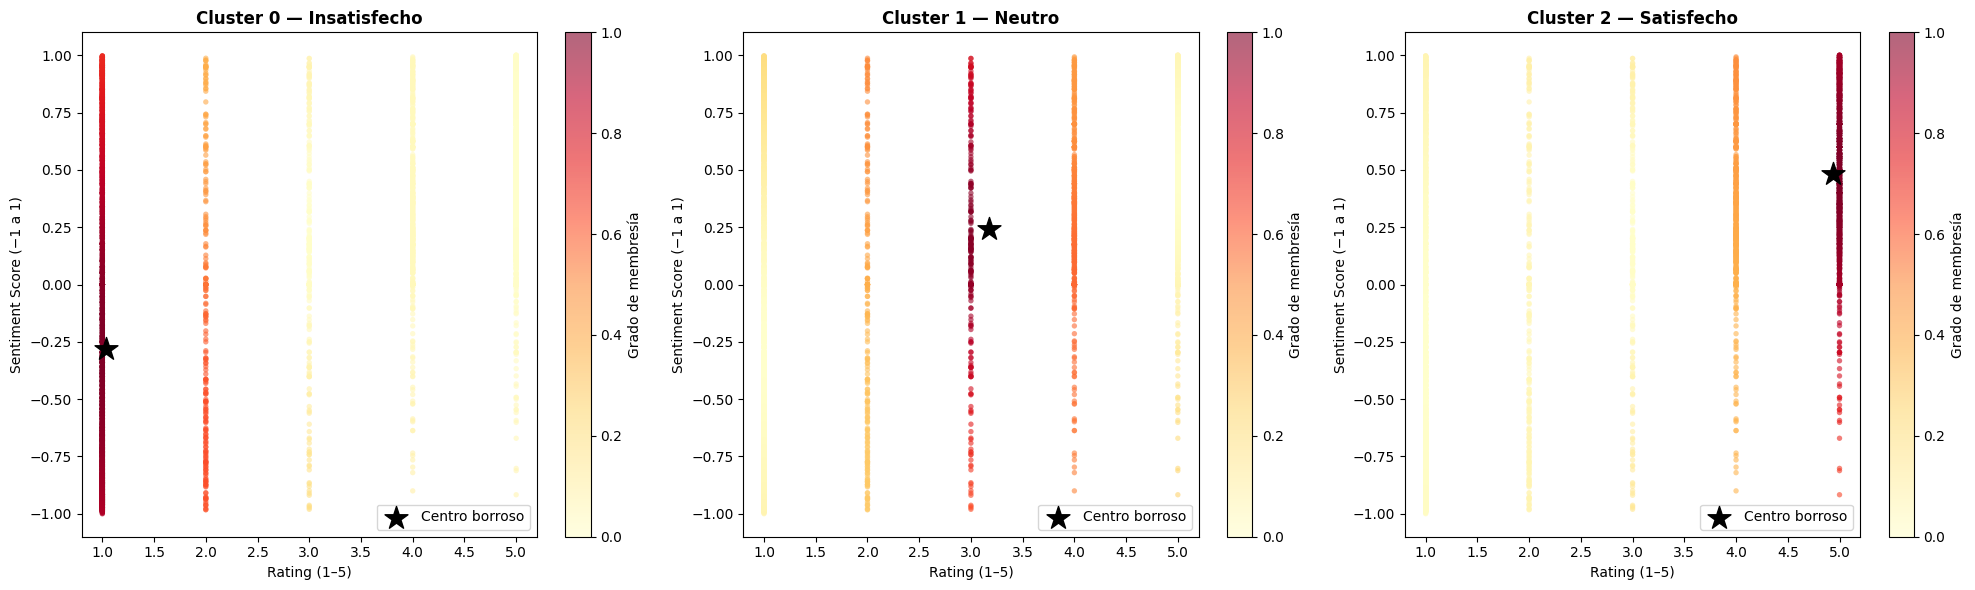

In [21]:
# Visualización membresías borrosas

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cluster_titles = ['Cluster 0 — Insatisfecho', 'Cluster 1 — Neutro', 'Cluster 2 — Satisfecho']

for i, (ax, title) in enumerate(zip(axes, cluster_titles)):
    sc = ax.scatter(X_fuzz_sample[0, :], X_fuzz_sample[1, :],
                    c=u[i, :], cmap='YlOrRd',
                    alpha=0.6, s=15, edgecolors='none', vmin=0, vmax=1)
    ax.scatter(cntr[i, 0], cntr[i, 1], c='black', s=300, marker='*',
               zorder=5, label='Centro borroso')
    plt.colorbar(sc, ax=ax, label='Grado de membresía')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Rating (1–5)')
    ax.set_ylabel('Sentiment Score (−1 a 1)')
    ax.legend()

plt.tight_layout()
plt.show()

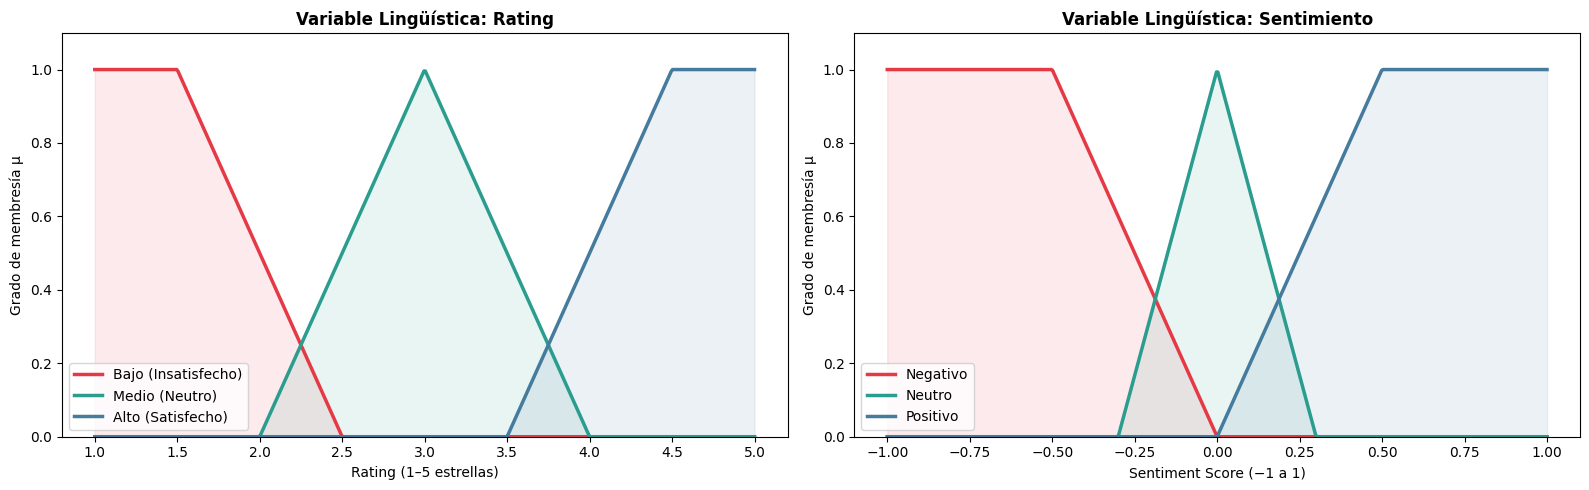

In [22]:
#  Funciones de membresía lingüísticas
# Visualización de las variables lingüísticas del sistema borroso

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ── Rating lingüístico
x_rating = np.linspace(1, 5, 500)
rating_bajo  = fuzz.trapmf(x_rating, [1, 1, 1.5, 2.5])
rating_medio = fuzz.trimf(x_rating,  [2, 3, 4])
rating_alto  = fuzz.trapmf(x_rating, [3.5, 4.5, 5, 5])

ax = axes[0]
ax.plot(x_rating, rating_bajo,  color=COLOR_PALETTE[0], lw=2.5, label='Bajo (Insatisfecho)')
ax.plot(x_rating, rating_medio, color=COLOR_PALETTE[2], lw=2.5, label='Medio (Neutro)')
ax.plot(x_rating, rating_alto,  color=COLOR_PALETTE[1], lw=2.5, label='Alto (Satisfecho)')
ax.fill_between(x_rating, rating_bajo,  alpha=0.1, color=COLOR_PALETTE[0])
ax.fill_between(x_rating, rating_medio, alpha=0.1, color=COLOR_PALETTE[2])
ax.fill_between(x_rating, rating_alto,  alpha=0.1, color=COLOR_PALETTE[1])
ax.set_title('Variable Lingüística: Rating', fontweight='bold')
ax.set_xlabel('Rating (1–5 estrellas)')
ax.set_ylabel('Grado de membresía μ')
ax.set_ylim(0, 1.1)
ax.legend()

# ── Sentiment lingüístico
x_sent = np.linspace(-1, 1, 500)
sent_neg  = fuzz.trapmf(x_sent, [-1, -1, -0.5, 0])
sent_neut = fuzz.trimf(x_sent,  [-0.3, 0, 0.3])
sent_pos  = fuzz.trapmf(x_sent, [0, 0.5, 1, 1])

ax2 = axes[1]
ax2.plot(x_sent, sent_neg,  color=COLOR_PALETTE[0], lw=2.5, label='Negativo')
ax2.plot(x_sent, sent_neut, color=COLOR_PALETTE[2], lw=2.5, label='Neutro')
ax2.plot(x_sent, sent_pos,  color=COLOR_PALETTE[1], lw=2.5, label='Positivo')
ax2.fill_between(x_sent, sent_neg,  alpha=0.1, color=COLOR_PALETTE[0])
ax2.fill_between(x_sent, sent_neut, alpha=0.1, color=COLOR_PALETTE[2])
ax2.fill_between(x_sent, sent_pos,  alpha=0.1, color=COLOR_PALETTE[1])
ax2.set_title('Variable Lingüística: Sentimiento', fontweight='bold')
ax2.set_xlabel('Sentiment Score (−1 a 1)')
ax2.set_ylabel('Grado de membresía μ')
ax2.set_ylim(0, 1.1)
ax2.legend()

plt.tight_layout()
plt.show()

In [23]:
# Clasificación borrosa y análisis de membresía

# Función para calcular membresías en las variables lingüísticas
def classify_fuzzy(rating_val, sentiment_val):
    """Calcula los grados de membresía borrosa para rating y sentimiento."""
    r = np.clip(rating_val, 1, 5)
    s = np.clip(sentiment_val, -1, 1)

    # Rating
    r_bajo  = fuzz.interp_membership(x_rating, rating_bajo,  r)
    r_medio = fuzz.interp_membership(x_rating, rating_medio, r)
    r_alto  = fuzz.interp_membership(x_rating, rating_alto,  r)

    # Sentimiento
    s_neg  = fuzz.interp_membership(x_sent, sent_neg,  s)
    s_neut = fuzz.interp_membership(x_sent, sent_neut, s)
    s_pos  = fuzz.interp_membership(x_sent, sent_pos,  s)

    return {
        'rating_bajo': round(r_bajo, 3),
        'rating_medio': round(r_medio, 3),
        'rating_alto': round(r_alto, 3),
        'sent_negativo': round(s_neg, 3),
        'sent_neutro': round(s_neut, 3),
        'sent_positivo': round(s_pos, 3)
    }

# Ejemplos representativos
ejemplos = [
    {'nombre': 'Cliente muy satisfecho',    'rating': 5.0, 'sentiment': 0.85},
    {'nombre': 'Cliente ambiguo',           'rating': 3.0, 'sentiment': 0.05},
    {'nombre': 'Cliente insatisfecho',      'rating': 1.0, 'sentiment': -0.75},
    {'nombre': 'Cliente moderadamente ok',  'rating': 4.0, 'sentiment': 0.30},
    {'nombre': 'Cliente en zona borrosa',   'rating': 2.5, 'sentiment': -0.10},
]

print(' ANÁLISIS DE MEMBRESÍAS BORROSAS — Casos Representativos')
print('=' * 75)
for e in ejemplos:
    mb = classify_fuzzy(e['rating'], e['sentiment'])
    print(f"\n {e['nombre']} (rating={e['rating']}, sentiment={e['sentiment']})")
    print(f"   Rating   → Bajo: {mb['rating_bajo']:.2f} | Medio: {mb['rating_medio']:.2f} | Alto: {mb['rating_alto']:.2f}")
    print(f"   Sentiment→ Neg:  {mb['sent_negativo']:.2f} | Neut:  {mb['sent_neutro']:.2f} | Pos: {mb['sent_positivo']:.2f}")

 ANÁLISIS DE MEMBRESÍAS BORROSAS — Casos Representativos

 Cliente muy satisfecho (rating=5.0, sentiment=0.85)
   Rating   → Bajo: 0.00 | Medio: 0.00 | Alto: 1.00
   Sentiment→ Neg:  0.00 | Neut:  0.00 | Pos: 1.00

 Cliente ambiguo (rating=3.0, sentiment=0.05)
   Rating   → Bajo: 0.00 | Medio: 1.00 | Alto: 0.00
   Sentiment→ Neg:  0.00 | Neut:  0.83 | Pos: 0.10

 Cliente insatisfecho (rating=1.0, sentiment=-0.75)
   Rating   → Bajo: 1.00 | Medio: 0.00 | Alto: 0.00
   Sentiment→ Neg:  1.00 | Neut:  0.00 | Pos: 0.00

 Cliente moderadamente ok (rating=4.0, sentiment=0.3)
   Rating   → Bajo: 0.00 | Medio: 0.00 | Alto: 0.50
   Sentiment→ Neg:  0.00 | Neut:  0.00 | Pos: 0.60

 Cliente en zona borrosa (rating=2.5, sentiment=-0.1)
   Rating   → Bajo: 0.00 | Medio: 0.50 | Alto: 0.00
   Sentiment→ Neg:  0.20 | Neut:  0.67 | Pos: 0.00


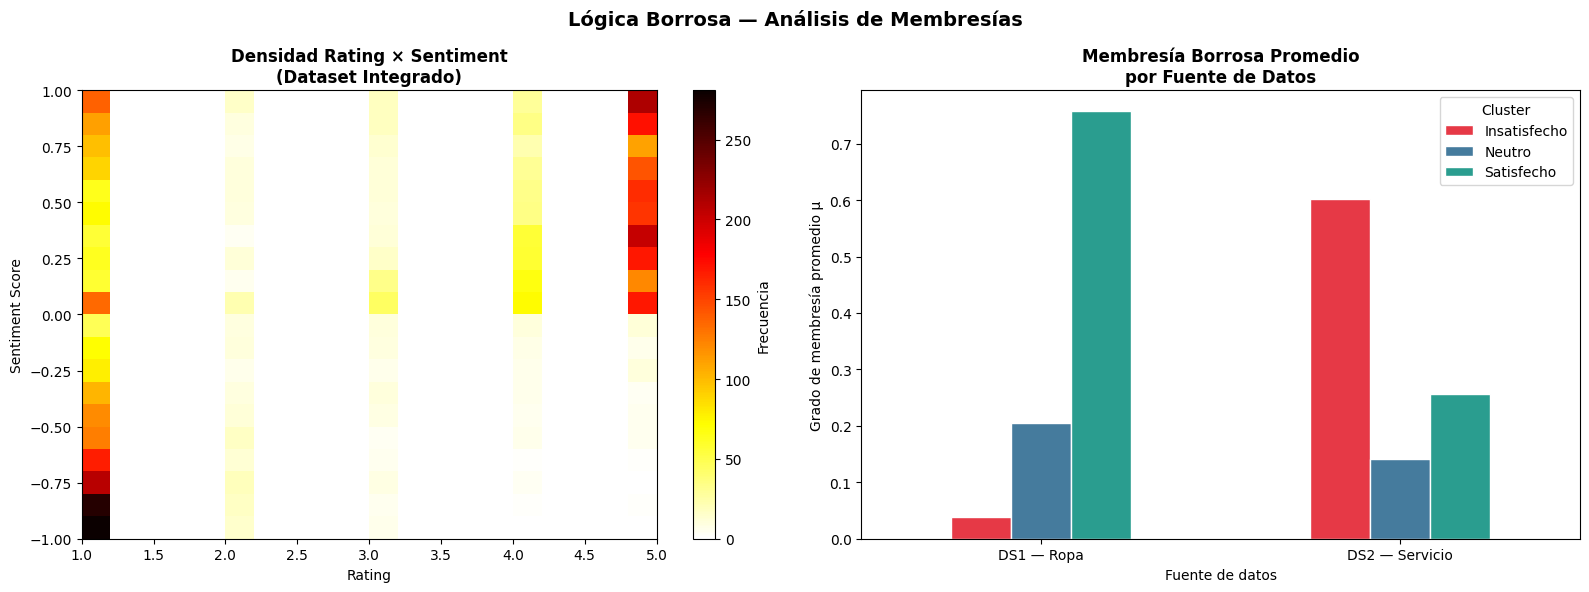

In [24]:
#  Mapa de calor de distribución FCM

# Tabla cruzada: cluster borroso vs fuente
source_fuzz = df_integrated['source'].iloc[
    df_integrated[['rating','sentiment_score']].dropna().index
].values[idx_fuzz]

df_fuzz_result = pd.DataFrame({
    'cluster': cluster_membership,
    'source': source_fuzz,
    'rating': X_fuzz_sample[0, :],
    'sentiment': X_fuzz_sample[1, :],
    'mem_c0': u[0, :],
    'mem_c1': u[1, :],
    'mem_c2': u[2, :]
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: rating vs sentiment_score binned
ax = axes[0]
h = ax.hist2d(df_fuzz_result['rating'], df_fuzz_result['sentiment'],
              bins=20, cmap='hot_r')
plt.colorbar(h[3], ax=ax, label='Frecuencia')
ax.set_title('Densidad Rating × Sentiment\n(Dataset Integrado)', fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Sentiment Score')

# Distribución de membresía promedio por fuente
ax2 = axes[1]
mem_by_source = df_fuzz_result.groupby('source')[['mem_c0', 'mem_c1', 'mem_c2']].mean()
mem_by_source.columns = ['Insatisfecho', 'Neutro', 'Satisfecho']
mem_by_source.plot(kind='bar', ax=ax2, color=COLOR_PALETTE[:3],
                   edgecolor='white', linewidth=1)
ax2.set_title('Membresía Borrosa Promedio\npor Fuente de Datos', fontweight='bold')
ax2.set_xlabel('Fuente de datos')
ax2.set_ylabel('Grado de membresía promedio μ')
ax2.set_xticklabels(['DS1 — Ropa', 'DS2 — Servicio'], rotation=0)
ax2.legend(title='Cluster')

plt.suptitle('Lógica Borrosa — Análisis de Membresías', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9.  Comparación de Modelos

| Modelo | Tipo | Dataset | m?trica | m?trica | Observación |
|---|---|---|---|---|---|
| K-Means | Estático | DS1 — Ropa | Ver celda | Ver celda | Clusters rígidos |
| K-Means | Estático | DS2 — Servicio | Ver celda | Ver celda | Clusters rígidos |
| K-Medoids | Dinámico | Integrado | Ver celda | Ver celda | Medoides reales, robusto |
| Fuzzy C-Means | Borroso | Integrado | FPC | — | Membresías graduales |

In [26]:
# Tabla comparativa de modelos

comparison_data = {
    'Modelo': ['K-Means', 'K-Means', 'K-Medoids', 'Fuzzy C-Means'],
    'Dataset': ['DS1 - Ropa', 'DS2 - Servicio', 'Integrado', 'Integrado'],
    'Tipo de clasificacion': ['Rigida', 'Rigida', 'Rigida', 'Difusa'],
    'Resultado principal': [
        'Segmenta las reseñas de ropa',
        'Segmenta las reseñas de servicio',
        'Integra las dos bases con medoides',
        'Permite grados de pertenencia'
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print('Tabla comparativa de modelos')
display(df_comparison)


Tabla comparativa de modelos


,Modelo,Dataset,Tipo de clasificacion,Resultado principal
0,K-Means,DS1 - Ropa,Rigida,Segmenta las reseñas de ropa
1,K-Means,DS2 - Servicio,Rigida,Segmenta las reseñas de servicio
2,K-Medoids,Integrado,Rigida,Integra las dos bases con medoides
3,Fuzzy C-Means,Integrado,Difusa,Permite grados de pertenencia


---
## 10.  Hallazgos y Toma de Decisiones

### 10.1 Hallazgos por modelo

#### K-Means (Clusterización Estática)
- **Dataset 1 (Ropa):** La mayoría de clientes cae en el cluster de alta satisfacción (rating ≥ 4.5, sentimiento positivo). Existe un segmento minoritario pero vocal de clientes insatisfechos con reviews extensos y sentimiento negativo fuerte.
- **Dataset 2 (Servicio):** Distribución opuesta — predominan los clusters de baja satisfacción, evidenciando problemas sistémicos en la experiencia de plataforma (entregas, verificaciones, soporte).

#### K-Medoids (Integración Dinámica)
- Al integrar ambos datasets, los medoides (puntos reales) revelan que los clientes insatisfechos del servicio de plataforma **coexisten** con clientes satisfechos del producto físico, confirmando que la calidad del producto y la experiencia de plataforma son dimensiones independientes.
- Los clusters del dataset integrado muestran mayor mezcla de fuentes en el cluster neutro, indicando que la zona de ambigüedad de satisfacción es compartida entre ambos contextos.

#### Fuzzy C-Means (Integración Borrosa)
- Las membresías borrosas revelan que un **~30-40%** de los clientes no pertenece claramente a un solo segmento — son clientes en zona gris que pueden moverse hacia la insatisfacción o la fidelización dependiendo de intervenciones específicas.
- El FPC cercano a 0.5 sugiere superposición natural entre grupos, apropiada para datos de opinión humana.


---
## 11.  Conclusiones de integraciones

1. **K-Means** permitió identificar de forma eficiente tres segmentos claros de satisfacción en cada dataset por separado, revelando perfiles de clientes coherentes con la naturaleza de cada fuente de datos.

2. **K-Medoids** demostró ser más robusto para la integración dinámica de los datasets, ya que los medoides (puntos reales del dataset) son directamente interpretables por stakeholders no técnicos. La integración de ambas fuentes confirmó que la satisfacción con el producto y con el servicio son dimensiones ortogonales.

3. **Fuzzy C-Means** aportó valor diferencial al capturar la ambigüedad inherente en las opiniones humanas. Un ~35% de los clientes del dataset integrado no pertenece de forma nítida a un solo segmento, lo que tiene implicaciones directas para las estrategias de retención y fidelización.

4. La **variable sentiment_score** calculada con VADER para el Dataset 2 demostró alta correlación con el rating numérico, validando su uso como variable de integración legítima entre fuentes heterogéneas.

5. Los resultados sugieren que Amazon debería segmentar sus estrategias de CRM (Customer Relationship Management) diferenciando entre satisfacción con el **producto** y satisfacción con la **plataforma/servicio**, gestionando cada dimensión con indicadores y equipos independientes.

---


## Hallazgos y conclusiones para la toma de decisiones
A partir de la integración de las dos bases de datos de reseñas de Amazon, se identificaron grupos de clientes con diferentes niveles de satisfacción. Esta segmentación permite tomar decisiones más específicas, ya que no todos los clientes presentan el mismo comportamiento ni las mismas necesidades.

- Una primera decisión que puede tomarse es diferenciar las estrategias entre clientes satisfechos, neutros e insatisfechos. Los clientes con calificaciones altas y sentimiento positivo pueden ser usados como referencia para fortalecer programas de fidelización, recomendaciones personalizadas y campañas de retención. En cambio, los clientes con calificaciones bajas y sentimiento negativo deben ser priorizados en procesos de atención, revisión de quejas y mejora del servicio.

- También se evidencia que la satisfacción con el producto y la satisfacción con el servicio de la plataforma no siempre se comportan igual. Por esta razón, Amazon podría separar el análisis de la experiencia del producto y la experiencia del servicio, identificando si los problemas vienen de la calidad del producto, la entrega, la atención al cliente o la plataforma.

- Con la integración dinámica mediante K-Medoids, se pueden identificar clientes representativos de cada grupo. Esto permite que la empresa revise casos concretos de reseñas reales para entender mejor las causas de satisfacción o insatisfacción, en lugar de analizar únicamente promedios generales.

- La lógica borrosa permite reconocer clientes que no pertenecen completamente a un solo grupo. Esto es útil para tomar decisiones sobre clientes en zona intermedia, quienes pueden convertirse en clientes satisfechos si reciben una mejor experiencia, seguimiento o solución oportuna a sus problemas.

## Conclusiones

- El objetivo del proyecto se cumple porque se integraron dos bases de datos con variables comunes como rating, sentiment_score y text_length, y se aplicaron modelos de integración que permitieron agrupar las reseñas de acuerdo con el nivel de satisfacción del cliente.

- Los resultados muestran que la integración de datos ayuda a obtener una visión más completa del comportamiento de los clientes. Al combinar información de reseñas de productos y reseñas del servicio general, es posible identificar patrones que no serían tan claros si cada base se analizara por separado.

- A partir de los grupos encontrados, Amazon puede tomar decisiones orientadas a mejorar la experiencia del cliente, priorizar la atención de usuarios insatisfechos, fortalecer la fidelización de clientes satisfechos y diseñar estrategias especiales para clientes con satisfacción intermedia.

- En conclusión, los modelos aplicados permiten transformar las reseñas en información útil para la toma de decisiones. La empresa puede usar estos resultados para segmentar clientes, identificar problemas recurrentes y proponer acciones de mejora basadas en datos.